## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from scipy.optimize import minimize
from datetime import datetime
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ec05-portfolio-variance'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'ecb': '7afd344000313ec2b4f6fb2548894e2a4817dc3687c14f8de47937ebf7bba0ad'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['ecb']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

In [3]:
def minimum_variance_weights(covariance):
    """Long-only fully invested variance minimization; no expected-return prediction."""
    covariance=np.asarray(covariance,dtype=float)
    if covariance.ndim!=2 or covariance.shape[0]!=covariance.shape[1] or len(covariance)<2 or not np.isfinite(covariance).all():
        raise ValueError('Need a finite square covariance matrix')
    if not np.allclose(covariance,covariance.T) or np.linalg.eigvalsh(covariance).min()<-1e-10:
        raise ValueError('Covariance must be symmetric positive semidefinite')
    n=len(covariance);initial=np.full(n,1/n)
    result=minimize(lambda w:1e4*float(w@covariance@w),initial,jac=lambda w:2e4*covariance@w,
        method='SLSQP',bounds=[(0,1)]*n,constraints={'type':'eq','fun':lambda w:w.sum()-1,'jac':lambda w:np.ones(n)},
        options={'ftol':1e-12,'maxiter':500})
    if not result.success:raise RuntimeError(result.message)
    weights=result.x
    if np.any(weights<-1e-8) or not np.isclose(weights.sum(),1):raise RuntimeError('Optimizer violated weight constraints')
    return weights

print("Method ready: minimum_variance_weights")


Method ready: minimum_variance_weights


In [4]:
def iso_datetimes(values):
    """Parse source ISO dates with the standard library; keep tables as ISO strings."""
    return [datetime.fromisoformat(str(value)) for value in values]

print("Method ready: iso_datetimes")


Method ready: iso_datetimes


### 数据与模型边界

历史价格型货币例子假设每日再平衡，不含利息/套息、费用、成交成本和税，不确定未来表现或构成投资建议。来源：ECB，原始参考汇率可在 ECB 免费取得。倒数、收益和风险统计为课程派生计算，不是 ECB 统计。

## 分步分析

### 1. 保留测试年并估计权重

2019–2022 估计协方差，2023–2024 测试。权重仅多头且和为一，年化采用声明的 252 观测约定。

Source: European Central Bank. The original reference rates are available free from the ECB. Course returns, inversions and risk estimates are derived calculations, not ECB statistics.
Quote: Foreign currency units per 1 EUR ; common complete dates: 1538 of 1538


,USD,GBP,JPY,CNY
date,,,,
2019-01-02,1.1397,0.90165,124.28,7.8165
2019-01-03,1.1348,0.90312,122.21,7.8019
2019-01-04,1.1403,0.89988,123.20,7.8280
2019-01-07,1.1445,0.89720,123.90,7.8421
2019-01-08,1.1440,0.89743,124.46,7.8405
2019-01-09,1.1455,0.89913,124.70,7.8226


,currency,minimum_variance_weight,equal_weight
0,USD,0.118891,0.25
1,GBP,0.376475,0.25
2,JPY,0.210420,0.25
3,CNY,0.294214,0.25


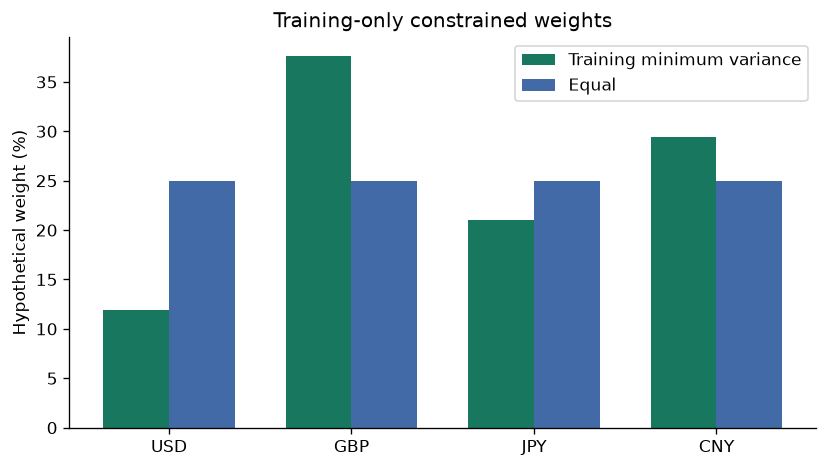

In [5]:
ecb=snapshot("ecb");rates=pd.DataFrame(ecb["rows"])
rates["date"]=rates["Date"].astype(str);rates=rates.set_index("date").sort_index()
currencies=ecb["currency_order"];original_dates=len(rates);rates=rates[currencies].dropna()
assert rates.index.is_unique and rates.index.is_monotonic_increasing and (rates>0).all().all()
prices=1/rates;returns=prices.pct_change(fill_method=None).iloc[1:]
print(ecb["source_notice"])
print("Quote:",ecb["quote"],"; common complete dates:",len(rates),"of",original_dates)
display(rates.head(6))
training=np.array([value.year<=2022 for value in iso_datetimes(returns.index)]);test=~training
assert returns.index[training].max()<returns.index[test].min()
covariance=returns.loc[training].cov().to_numpy();weights=minimum_variance_weights(covariance)
equal=np.full(4,.25);annualization=252
display(pd.DataFrame({"currency":currencies,"minimum_variance_weight":weights,"equal_weight":equal}))
fig,ax=plt.subplots(figsize=(7,4));positions=np.arange(4)
ax.bar(positions-.18,100*weights,width=.36,label="Training minimum variance");ax.bar(positions+.18,100*equal,width=.36,label="Equal")
ax.set_xticks(positions,currencies);ax.set(ylabel="Hypothetical weight (%)",title="Training-only constrained weights");ax.legend();plt.tight_layout();plt.show()


### 2. 比较历史训练/测试波动

两时段固定训练权重，日样本标准差乘 sqrt(252) 为约定，不是确切自然年数量。训练最优不一定在测试最佳。

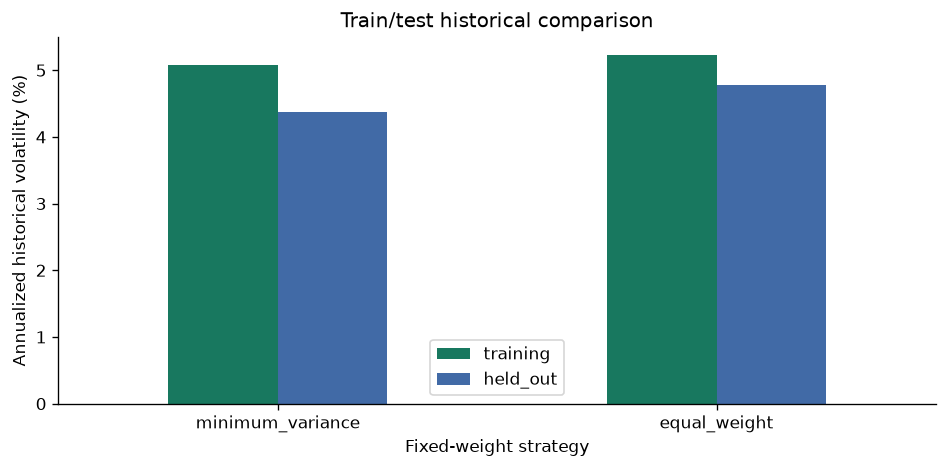

In [6]:
series=pd.DataFrame({"minimum_variance":returns.to_numpy()@weights,"equal_weight":returns.to_numpy()@equal},index=returns.index)
volatility=pd.DataFrame({"training":[100*series.loc[training,c].std(ddof=1)*np.sqrt(annualization) for c in series],"held_out":[100*series.loc[test,c].std(ddof=1)*np.sqrt(annualization) for c in series]},index=series.columns)
fig,ax=plt.subplots(figsize=(8,4));volatility.plot.bar(ax=ax)
ax.set(ylabel="Annualized historical volatility (%)",xlabel="Fixed-weight strategy",title="Train/test historical comparison");plt.xticks(rotation=0);plt.tight_layout();plt.show()


### 3. 解读假设价格增长

cumprod(1+r) 构造从 100 开始的无摩擦日再平衡指数，不含利息/套息、税与成交成本，不是真实投资盈利。

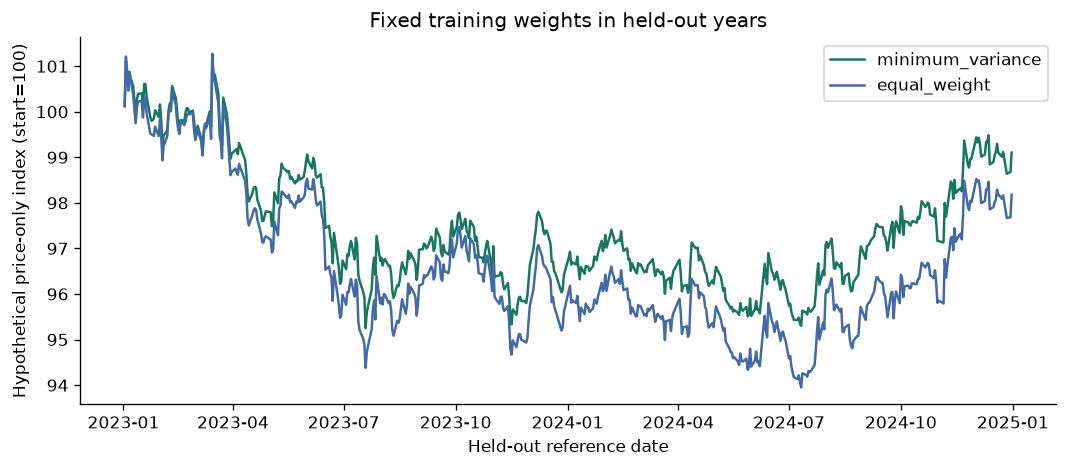

In [7]:
growth=100*(1+series.loc[test]).cumprod()
fig,ax=plt.subplots(figsize=(9,4))
for code in growth:ax.plot(iso_datetimes(growth.index),growth[code],label=code)
ax.legend()
ax.set(xlabel="Held-out reference date",ylabel="Hypothetical price-only index (start=100)",title="Fixed training weights in held-out years");plt.tight_layout();plt.show()


### 4. 检查约束及可行基线

权重范围/和及协方差对称须通过，训练优化方差不应超过等权可行目标的容差，不据此证明未来适用。

In [8]:
assert np.isclose(weights.sum(),1) and np.all(weights>=-1e-8) and np.all(weights<=1+1e-8)
assert np.allclose(covariance,covariance.T)
assert weights@covariance@weights<=equal@covariance@equal+1e-10
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"currency":currencies,"weight":weights}).to_csv(OUTPUT_DIR/"training-only-weights.csv",index=False)
series.to_csv(OUTPUT_DIR/"hypothetical-price-returns.csv");volatility.to_csv(OUTPUT_DIR/"historical-volatility.csv")
(OUTPUT_DIR/"assumptions.json").write_text(json.dumps({"training_years":[2019,2022],"held_out_years":[2023,2024],"denomination":"EUR","interest_and_carry_included":False,"costs_and_tax_included":False,"rebalancing":"daily fixed weights","annualization_observations":252},indent=2))
print("Constraint and training-objective checks passed; exports:",OUTPUT_DIR)


Constraint and training-objective checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ec05-portfolio-variance


## 自主练习与参考答案

1. 训练最优为何可能随后失效？
2. 排除哪些成本/收益？

**参考解释。** 协方差会变化；假设价格模型省略利息/套息、税及成交成本。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 仅用 NumPy、SciPy、Pandas、Matplotlib 比较训练窗口，在同测试期固定权重。

**提示词 2**

> 同包增加声明的权重上限并核对可行。

**人工验收。** 权重和为一且有界，只用训练协方差，不宣称未来适用。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [9]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://data-api.ecb.europa.eu/service/data/EXR/D.USD.EUR.SP00.A?startPeriod=2024-01-01&endPeriod=2024-12-31&format=csvdata',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [ECB SDMX euro reference exchange rates](https://data-api.ecb.europa.eu/service/data/EXR/D.USD+GBP+JPY+CNY.EUR.SP00.A?startPeriod=2019-01-01&endPeriod=2024-12-31&format=csvdata) — ECB copyright / free reuse with accurate source attribution; data obtained free from ECB; derived returns explicitly labelled; retrieved 2026-10-09. SHA-256 `5f39fc39f60606abafae26c00492d05388c7bdf29cce1922f173f99bd0273ce8`.
  Retain 2019-01-01 through 2024-12-31 and USD, GBP, JPY, CNY; preserve missing values and quotation direction.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。